# 01 — Exploratory Data Analysis: South German Credit Data

## What is this dataset?

This is the **South German Credit dataset** (Grömping, 2019 corrected
version of the classic UCI "German Credit" dataset). It contains **1,000
real loan applications** from a German bank, with **20 features** describing
each applicant (financial status, loan details, demographics) plus **1
target column**: whether the loan was ultimately a **good** or **bad**
credit outcome.

All columns in the original file used German abbreviations and **numeric
codes** for categorical values (e.g. checking account status is coded
1-4, not written out as text). We already renamed the columns to English
in `src/data_prep.py` — this notebook picks up the cleaned file. The
category codes themselves are left as numbers here (as defined in the
original dataset codebook), rather than guessed at, since we don't want
to invent label text that wasn't given to us.

## Why is this suited for credit risk modeling?

This is essentially a **loan underwriting dataset**: for each applicant,
we know what a bank knew (or could have known) *before* deciding to grant
the loan — account status, credit history, loan purpose/amount/duration,
employment, savings, age, etc. — plus the **actual outcome** of that loan.
That's exactly the structure needed to build a **Probability of Default
(PD) model**, which is the core building block of an **Expected Credit
Loss (ECL)** model (ECL ≈ PD × LGD × EAD, as used under IFRS 9 / CECL).

## What does "good" vs "bad" credit mean here?

The target column is `credit_risk`:

- **`1` = good credit** — the applicant repaid the loan as agreed.
- **`0` = bad credit** — the applicant defaulted / did not repay as agreed.

This notebook only explores the data — **no modeling yet**. The goal here
is to understand the data's shape, class balance, and how a handful of key
features relate to default risk, before we build any predictive model.


## Setup

We import the libraries we need:
- **pandas** to load and manipulate the tabular data.
- **matplotlib** / **seaborn** to make plots. Seaborn sits on top of
  matplotlib and gives nicer default styling for statistical plots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# A consistent, clean plot style for the whole notebook.
sns.set_theme(style="whitegrid")

# Build paths relative to the project root (this notebook lives in
# notebooks/, so the project root is one level up).
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "credit_clean.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load the cleaned data

We load the file that `src/data_prep.py` already cleaned and saved —
English column names, verified no nulls or duplicates. `.head()` shows the
first 5 rows so we can eyeball that everything loaded correctly, and
`.shape` tells us (rows, columns).

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 1000 rows x 21 columns


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


## Class balance: good vs bad credit

`kredit`/`credit_risk` is our target. Let's check how many applicants
fall into each class.

**Why does class imbalance matter for modeling?**

With 700 good (70%) and 300 bad (30%), the dataset is **imbalanced**
(not 50/50). This matters because:

1. A model that just predicts "good" for *everyone* would already be
   70% "accurate" — so plain accuracy is a misleading metric here. We'll
   need metrics like **recall on the bad class, precision, AUC, or a
   confusion matrix** later, not just accuracy.
2. Many classifiers implicitly optimize for the majority class unless
   told otherwise (e.g. via class weights or resampling), so an imbalanced
   training set can produce a model that's bad at catching actual
   defaults — which, for a credit risk model, is the exact thing we most
   need to catch.
3. In ECL modeling specifically, underestimating who's likely to default
   directly understates expected credit losses — so this is not just a
   modeling technicality, it has real financial-reporting consequences.

We're flagging this now; we'll address it properly (e.g. class weights,
stratified train/test splits) in the modeling stage — not in this
notebook.

                 count   pct
credit_risk                 
Bad credit (0)     300  30.0
Good credit (1)    700  70.0


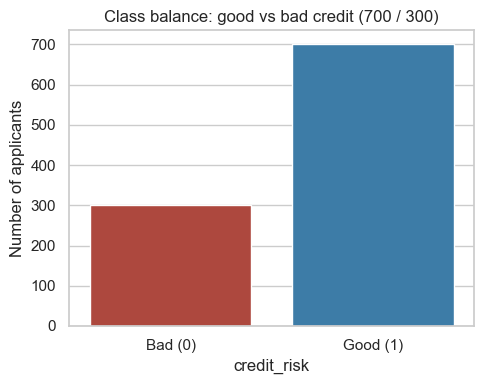

In [3]:
# Raw counts and percentages per class.
counts = df["credit_risk"].value_counts().sort_index()
pct = df["credit_risk"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({"count": counts, "pct": pct.round(1)})
summary.index = summary.index.map({0: "Bad credit (0)", 1: "Good credit (1)"})
print(summary)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="credit_risk", hue="credit_risk",
              palette={0: "#c0392b", 1: "#2c7fb8"}, legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Bad (0)", "Good (1)"])
ax.set_xlabel("credit_risk")
ax.set_ylabel("Number of applicants")
ax.set_title("Class balance: good vs bad credit (700 / 300)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_balance.png", dpi=150)
plt.show()

## Default rate against key features

For each feature below, we compute the **default rate** — the percentage
of applicants in each group whose `credit_risk == 0` (bad credit) — and
plot it. A higher bar means that group defaulted more often.

For the two categorical features (`status`, `credit_history`) we group by
their raw numeric codes as given in the dataset (we're not inventing text
labels for codes that weren't specified). For the two continuous features
(`duration`, `age`) we first bucket the values into ranges (using
`pd.cut`), since a default rate "at exactly age 37" isn't a meaningful
group on its own — but "ages 36-45" is.

### A small helper function

Since we're about to compute "default rate per group" four times, we write
one small reusable function instead of repeating the same
`groupby(...).mean()` logic four times. This is standard pandas practice:
`groupby(column)["credit_risk"]` splits the data into groups by that
column, and `.mean()` on a 0/1 column gives the *proportion* of 1s in each
group (proportion good). We then convert "proportion good" into "default
rate" as `(1 - proportion good) * 100`.

In [4]:
def default_rate_by_group(data: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Return default rate (%) and applicant count for each group in group_col."""
    grouped = data.groupby(group_col)["credit_risk"].agg(["mean", "count"])
    grouped["default_rate_pct"] = (1 - grouped["mean"]) * 100
    return grouped[["default_rate_pct", "count"]].rename(columns={"count": "n_applicants"})


def plot_default_rate(data: pd.DataFrame, group_col: str, title: str, xlabel: str):
    """Bar plot of default rate (%) per group, with sample size annotated."""
    result = default_rate_by_group(data, group_col)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(result.index.astype(str), result["default_rate_pct"], color="#c0392b")
    ax.axhline(30.0, color="gray", linestyle="--", linewidth=1,
               label="Overall default rate (30%)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Default rate (%)")
    ax.set_title(title)
    ax.legend()

    # Annotate each bar with its sample size, so we can see if a group's
    # default rate is based on a handful of applicants or hundreds.
    for bar, n in zip(bars, result["n_applicants"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"n={n}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"default_rate_by_{group_col}.png", dpi=150)
    plt.show()
    return result

### 1. Default rate by checking account status (`status`)

`status` (originally `laufkont`) is coded 1-4 and describes the
applicant's checking account status at the bank. We weren't given the
exact meaning of each numeric code, so we plot by raw code rather than
guessing at labels — the pattern across codes is still informative on its
own, and this is usually one of the strongest predictors in this
dataset.

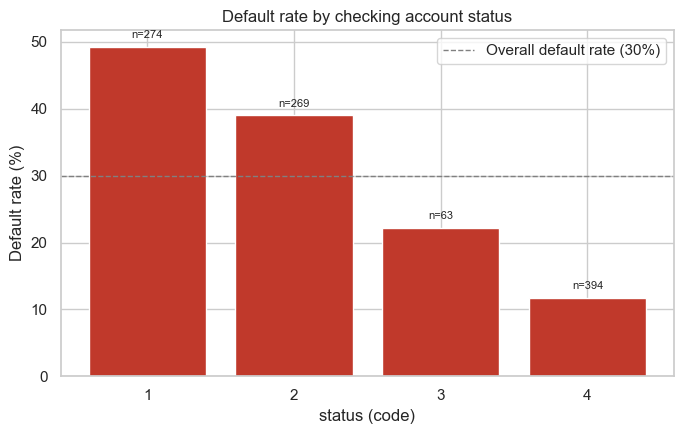

,default_rate_pct,n_applicants
status,,
1,49.270073,274
2,39.033457,269
3,22.222222,63
4,11.675127,394


In [5]:
plot_default_rate(df, "status", "Default rate by checking account status", "status (code)")

### 2. Default rate by credit history (`credit_history`)

`credit_history` (originally `moral`) is coded 0-4 and reflects how the
applicant has handled past credit. Again, we don't have the exact
per-code definitions, so we plot by raw code. Intuitively we might expect
a monotonic relationship (worse-sounding history -> higher default rate),
but it's worth checking empirically rather than assuming — real data
often surprises you here.

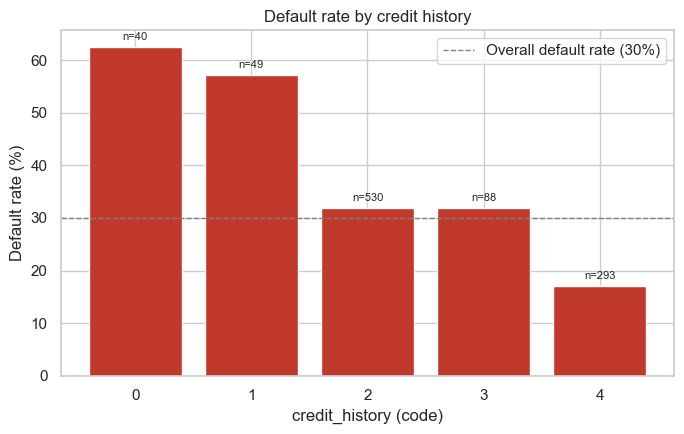

,default_rate_pct,n_applicants
credit_history,,
0,62.500000,40
1,57.142857,49
2,31.886792,530
3,31.818182,88
4,17.064846,293


In [6]:
plot_default_rate(df, "credit_history", "Default rate by credit history", "credit_history (code)")

### 3. Default rate by loan duration (`duration`)

`duration` is the loan length in months (ranges from 4 to 72 months in
this data). We bucket it into 6 ranges with `pd.cut` so each bar
represents a meaningful group of applicants rather than one applicant per
exact month value.

C:\Users\mitwi\AppData\Local\Temp\ipykernel_20748\2593047047.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(group_col)["credit_risk"].agg(["mean", "count"])


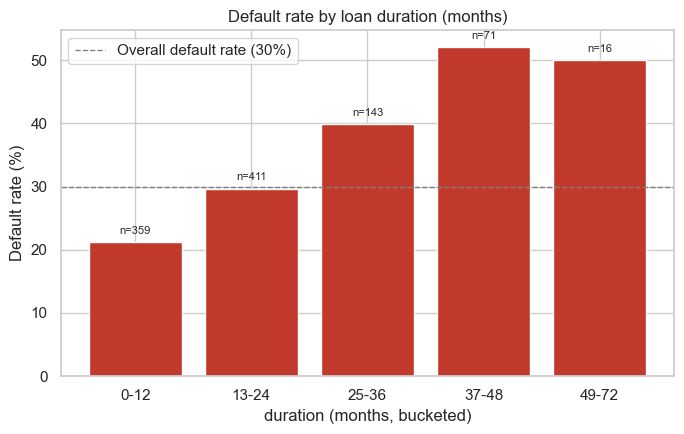

,default_rate_pct,n_applicants
duration_bucket,,
0-12,21.169916,359
13-24,29.683698,411
25-36,39.860140,143
37-48,52.112676,71
49-72,50.000000,16


In [7]:
bins = [0, 12, 24, 36, 48, 72]
labels = ["0-12", "13-24", "25-36", "37-48", "49-72"]
df["duration_bucket"] = pd.cut(df["duration"], bins=bins, labels=labels)

plot_default_rate(df, "duration_bucket", "Default rate by loan duration (months)", "duration (months, bucketed)")

### 4. Default rate by age (`age`)

`age` ranges from 19 to 75 in this data. We bucket it the same way, into
5 age ranges.

C:\Users\mitwi\AppData\Local\Temp\ipykernel_20748\2593047047.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(group_col)["credit_risk"].agg(["mean", "count"])


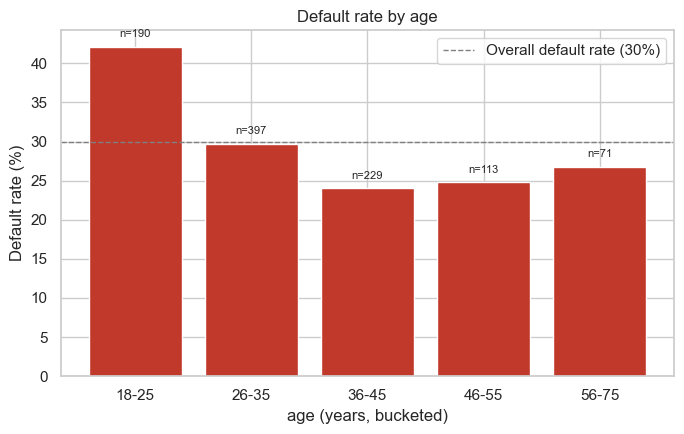

,default_rate_pct,n_applicants
age_bucket,,
18-25,42.105263,190
26-35,29.722922,397
36-45,24.017467,229
46-55,24.778761,113
56-75,26.760563,71


In [8]:
bins = [18, 25, 35, 45, 55, 75]
labels = ["18-25", "26-35", "36-45", "46-55", "56-75"]
df["age_bucket"] = pd.cut(df["age"], bins=bins, labels=labels)

plot_default_rate(df, "age_bucket", "Default rate by age", "age (years, bucketed)")

## Next steps

This notebook only covers loading, class balance, and default rate vs. 4
key features — no modeling. Natural next steps (in a later notebook /
script, not here) would be:

- Explore the remaining features similarly (savings, employment duration,
  purpose, property, housing, etc.).
- Check for multicollinearity between features.
- Decide on an encoding strategy for the numeric-coded categoricals ahead
  of modeling (e.g. one-hot vs. treating some as ordinal).
- Build a train/test split (stratified, given the class imbalance noted
  above) and a baseline Probability-of-Default model.